# Temporal Extrapolation & Attention Score Analysis: RoTHP vs HoTHP

This notebook tests the central hypothesis of HoTHP:

> RoTHP's trigonometric rotation creates oscillatory attention patterns that degrade when
> temporal distances exceed the range seen during training.  HoTHP's hyperbolic rotation
> should maintain monotonic decay and extrapolate more stably.

## Experiment Design

1. **Dataset**: Hawkes process with power-law kernel, generating sequences with a wide
   range of inter-event deltas.
2. **Training regime**: train on sequences where max normalized delta <= T_train.
3. **Test splits**: evaluate on bins of increasing temporal distance, including
   deltas **beyond** T_train (extrapolation regime).
4. **Attention profile**: fix q,k vectors and plot raw attention score vs delta_t
   for both RoTHP and HoTHP, showing the oscillation vs monotonic decay contrast.
5. **Learned attention weights**: extract actual attention weights from trained models
   and plot average attention as a function of temporal lag.


In [1]:
import os, sys, json, math, random, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

BASE_SEED = 42

def set_global_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

def make_run_seed(*parts, base_seed=BASE_SEED):
    key = '::'.join(map(str, parts))
    return (base_seed + int(hashlib.sha256(key.encode()).hexdigest()[:8], 16)) % (2**31)

set_global_seed(BASE_SEED)
sns.set_theme(style='whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if not os.path.exists('ufc-easytpp'):
    !git clone https://github.com/hugoramos/ufc-easytpp.git
if 'ufc-easytpp' not in sys.path:
    sys.path.insert(0, os.path.abspath('ufc-easytpp'))

import easy_tpp.model.torch_model.torch_baselayer as baselayer

def attention_fixed(query, key, value, mask=None, dropout=None):
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / (d_k ** 0.5)
    if mask is not None:
        if mask.dim() == 3: mask = mask.unsqueeze(1)
        scores = scores.masked_fill(mask > 0, -1e4)
    p_attn = torch.softmax(scores, dim=-1)
    if dropout is not None: p_attn = dropout(p_attn)
    return torch.matmul(p_attn, value), p_attn

baselayer.attention = attention_fixed
import easy_tpp.model.torch_model.torch_rothp as rothp_module
rothp_module.attention = attention_fixed

from easy_tpp.config_factory.model_config import ModelConfig
from easy_tpp.model.torch_model.torch_thp import THP
from easy_tpp.model.torch_model.torch_rothp import RoTHP, RotaryEmbedding
from easy_tpp.model.torch_model.torch_hothp import HoTHP

print(f'Device: {device}')
print(f'Seed: {BASE_SEED}')

Cloning into 'ufc-easytpp'...
remote: Enumerating objects: 457, done.
remote: Counting objects: 100% (457/457), done.
remote: Compressing objects: 100% (331/331), done.
remote: Total 457 (delta 141), reused 423 (delta 107), pack-reused 0 (from 0)
Receiving objects: 100% (457/457), 18.07 MiB | 8.53 MiB/s, done.
Resolving deltas: 100% (141/141), done.
Device: cpu
Seed: 42


## Part 1: Theoretical Attention Score Profile (no training needed)

This reproduces the key figure from the HoPE paper but in TPP context:
fix a pair of q,k vectors and plot the raw attention score contribution
from the positional encoding as a function of temporal distance delta_t.


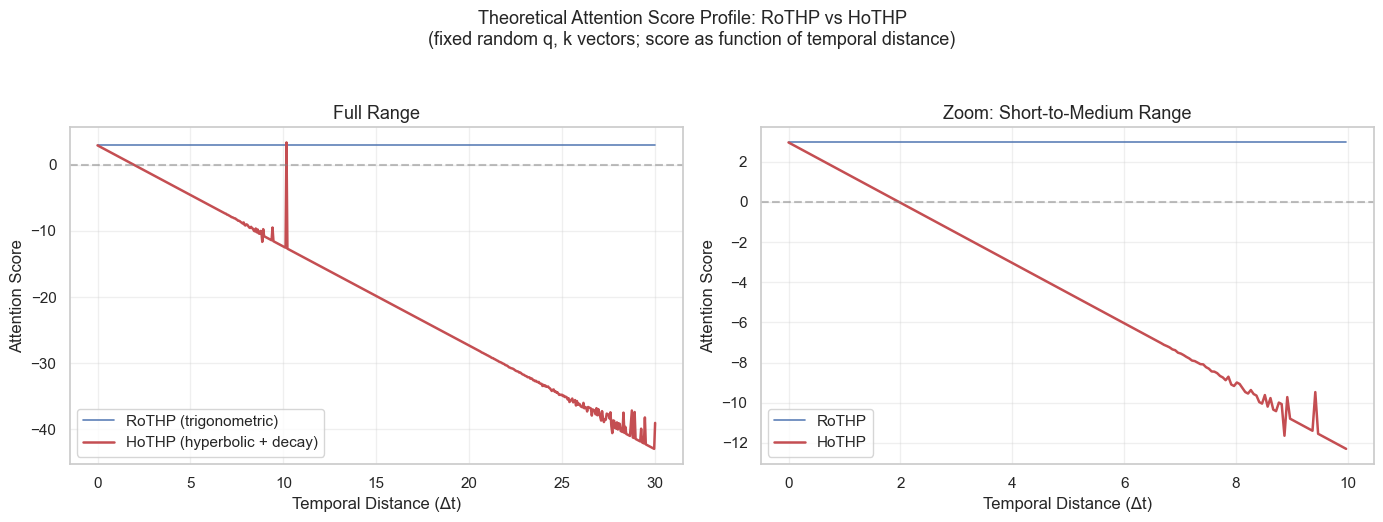

theta_prime (HoTHP) = 1.5000
max theta_i = 1.0000
RoPE score range: [2.96, 2.96]
HoPE score range: [-42.97, 3.40]


In [2]:
"""
Theoretical attention score as a function of temporal distance delta_t.

For RoPE/RoTHP the relative-position kernel is:
    score(delta) = sum_j [ q_j^T R(delta * theta_j) k_j ]
which is a sum of cosines -> oscillatory.

For HoPE/HoTHP the kernel is (Eq. 9 of Dai et al., 2025):
    score(delta) = exp(-delta * theta') * sum_j [ q_j^T B(delta * theta_j) k_j ]
where B is the Lorentz boost (hyperbolic rotation) and exp(-delta*theta')
is a MULTIPLICATIVE decay factor.  Since theta' > max(theta_j), the
exponential decay dominates the cosh/sinh growth, giving monotonic decay.

We compute these analytically in relative-distance space.
"""
from easy_tpp.model.torch_model.torch_hothp import HyperbolicRotaryEmbedding
import math as _math

dim = 16
n_deltas = 600
max_delta = 30.0

deltas = torch.linspace(0.0, max_delta, n_deltas)

torch.manual_seed(42)
q1 = torch.randn(dim // 2)
q2 = torch.randn(dim // 2)
k1 = torch.randn(dim // 2)
k2 = torch.randn(dim // 2)

thetas = torch.tensor([10000 ** (-2.0 * (j - 1) / dim) for j in range(1, dim // 2 + 1)])

hope_emb = HyperbolicRotaryEmbedding(dim)
theta_prime = hope_emb.theta_prime.item()

scores_rope_full = torch.zeros(n_deltas)
scores_hope_full = torch.zeros(n_deltas)

for i, dt in enumerate(deltas):
    rope_s = 0.0
    hope_s = 0.0
    for j in range(dim // 2):
        arg = dt.item() * thetas[j].item()

        # RoPE: q_rot^T k_rot via trigonometric rotation R(delta*theta)
        c, s = _math.cos(arg), _math.sin(arg)
        qr1 = q1[j].item() * c - q2[j].item() * s
        qr2 = q1[j].item() * s + q2[j].item() * c
        kr1 = k1[j].item() * c - k2[j].item() * s
        kr2 = k1[j].item() * s + k2[j].item() * c
        rope_s += qr1 * kr1 + qr2 * kr2

        # HoPE: q^T B(delta*theta) k via Lorentz boost (Eq. 5-6)
        ch = _math.cosh(arg)
        sh = _math.sinh(arg)
        hope_s += ((q1[j]*k1[j] + q2[j]*k2[j]).item() * ch +
                   (q1[j]*k2[j] + q2[j]*k1[j]).item() * sh)

    scores_rope_full[i] = rope_s
    # Eq. 9: MULTIPLICATIVE decay (not additive bias)
    scores_hope_full[i] = _math.exp(-dt.item() * theta_prime) * hope_s

scores_rope_np = scores_rope_full.numpy()
scores_hope_np = scores_hope_full.numpy()

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deltas.numpy(), scores_rope_np, color='#4C72B0', linewidth=1.2, alpha=0.9, label='RoTHP (trigonometric)')
axes[0].plot(deltas.numpy(), scores_hope_np, color='#C44E52', linewidth=1.8, label='HoTHP (hyperbolic + decay)')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Temporal Distance (Δt)', fontsize=12)
axes[0].set_ylabel('Attention Score', fontsize=12)
axes[0].set_title('Full Range', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

zoom_n = n_deltas // 3
axes[1].plot(deltas.numpy()[:zoom_n], scores_rope_np[:zoom_n], color='#4C72B0', linewidth=1.2, alpha=0.9, label='RoTHP')
axes[1].plot(deltas.numpy()[:zoom_n], scores_hope_np[:zoom_n], color='#C44E52', linewidth=1.8, label='HoTHP')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Temporal Distance (Δt)', fontsize=12)
axes[1].set_ylabel('Attention Score', fontsize=12)
axes[1].set_title('Zoom: Short-to-Medium Range', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Theoretical Attention Score Profile: RoTHP vs HoTHP\n'
             '(Eq. 9: multiplicative decay exp(-Δt·θ\') × q^T B(Δt·θ) k)',
             fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig('Attention_Score_Profile_RoTHP_vs_HoTHP.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'theta_prime (HoTHP) = {theta_prime:.4f}')
print(f'max theta_i = {thetas.max().item():.4f}')
print(f'theta\' > max(theta_i): {theta_prime > thetas.max().item()} (required by Eq. 12)')
print(f'RoPE score range: [{scores_rope_np.min():.2f}, {scores_rope_np.max():.2f}]')
print(f'HoPE score range: [{scores_hope_np.min():.4f}, {scores_hope_np.max():.4f}]')

## Part 2: Synthetic Dataset for Extrapolation Test

Generate a Hawkes process where:
- Training sequences have normalized deltas up to ~T_train
- Test sequences include deltas significantly beyond T_train
- This forces the model to extrapolate temporally


In [3]:
NUM_TYPES = 4
T_TRAIN_MAX = 8.0
T_EXTRAP_MAX = 40.0

def generate_hawkes_mixed_range(rng, num_types, horizon, mu, alpha, beta_fast, beta_slow, w_fast, w_slow, min_events=60, max_events=200):
    while True:
        events = []
        t = 0.0
        while t < horizon and len(events) < max_events:
            intensity = mu.copy()
            for t_i, k_i in events:
                dt = t - t_i
                kernel_val = w_fast * np.exp(-beta_fast * dt) + w_slow * np.exp(-beta_slow * dt)
                intensity += alpha[:, k_i] * kernel_val
            lam_bar = float(np.sum(intensity))
            if lam_bar <= 1e-9:
                break
            t += rng.exponential(1.0 / lam_bar)
            if t >= horizon:
                break
            candidate = mu.copy()
            for t_i, k_i in events:
                dt = t - t_i
                kernel_val = w_fast * np.exp(-beta_fast * dt) + w_slow * np.exp(-beta_slow * dt)
                candidate += alpha[:, k_i] * kernel_val
            lam_sum = float(np.sum(candidate))
            if rng.uniform() <= lam_sum / lam_bar:
                probs = candidate / lam_sum
                events.append((t, int(rng.choice(num_types, p=probs))))
        if len(events) >= min_events:
            return events[:max_events]


def inject_long_gaps(events, rng, num_gaps=3, gap_range=(15.0, 35.0)):
    events = sorted(events, key=lambda x: x[0])
    n = len(events)
    insert_positions = sorted(rng.choice(range(n // 4, 3 * n // 4), size=num_gaps, replace=False))

    new_events = []
    cumulative_shift = 0.0
    pos_idx = 0

    for i, (t, k) in enumerate(events):
        if pos_idx < len(insert_positions) and i == insert_positions[pos_idx]:
            gap = float(rng.uniform(*gap_range))
            cumulative_shift += gap
            pos_idx += 1
        new_events.append((t + cumulative_shift, k))

    return new_events


mu = np.array([0.12, 0.10, 0.09, 0.08])
alpha = np.array([
    [0.30, 0.08, 0.05, 0.03],
    [0.06, 0.28, 0.07, 0.04],
    [0.04, 0.06, 0.26, 0.06],
    [0.03, 0.04, 0.05, 0.24],
])
beta_fast = 2.5
beta_slow = 0.15
w_fast = 0.6
w_slow = 0.4

rng = np.random.default_rng(BASE_SEED)

train_seqs = []
for _ in tqdm(range(500), desc='Generating train (short range)'):
    events = generate_hawkes_mixed_range(rng, NUM_TYPES, horizon=50.0,
        mu=mu, alpha=alpha, beta_fast=beta_fast, beta_slow=beta_slow, w_fast=w_fast, w_slow=w_slow)
    train_seqs.append(events)

val_seqs = []
for _ in tqdm(range(100), desc='Generating val (short range)'):
    events = generate_hawkes_mixed_range(rng, NUM_TYPES, horizon=50.0,
        mu=mu, alpha=alpha, beta_fast=beta_fast, beta_slow=beta_slow, w_fast=w_fast, w_slow=w_slow)
    val_seqs.append(events)

test_short_seqs = []
for _ in tqdm(range(100), desc='Generating test-short'):
    events = generate_hawkes_mixed_range(rng, NUM_TYPES, horizon=50.0,
        mu=mu, alpha=alpha, beta_fast=beta_fast, beta_slow=beta_slow, w_fast=w_fast, w_slow=w_slow)
    test_short_seqs.append(events)

test_extrap_seqs = []
for _ in tqdm(range(100), desc='Generating test-extrapolation (with long gaps)'):
    events = generate_hawkes_mixed_range(rng, NUM_TYPES, horizon=50.0,
        mu=mu, alpha=alpha, beta_fast=beta_fast, beta_slow=beta_slow, w_fast=w_fast, w_slow=w_slow)
    events = inject_long_gaps(events, rng, num_gaps=3, gap_range=(15.0, 35.0))
    test_extrap_seqs.append(events)

def compute_delta_stats(seqs):
    all_deltas = []
    for seq in seqs:
        times = [t for t, _ in sorted(seq)]
        deltas = [times[i] - times[i-1] for i in range(1, len(times))]
        all_deltas.extend(deltas)
    arr = np.array(all_deltas)
    return {'mean': arr.mean(), 'median': np.median(arr), 'p90': np.quantile(arr, 0.9),
            'p99': np.quantile(arr, 0.99), 'max': arr.max()}

print('Train delta stats:', compute_delta_stats(train_seqs))
print('Val delta stats:', compute_delta_stats(val_seqs))
print('Test-short delta stats:', compute_delta_stats(test_short_seqs))
print('Test-extrap delta stats:', compute_delta_stats(test_extrap_seqs))

Generating train (short range):   0%|          | 0/500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
def convert_to_tensors(seqs, num_types, time_norm):
    converted = []
    for seq in seqs:
        seq = sorted(seq, key=lambda x: x[0])
        times = torch.tensor([t for t, _ in seq], dtype=torch.float32)
        types = torch.tensor([k for _, k in seq], dtype=torch.long)
        deltas = torch.zeros_like(times)
        deltas[0] = times[0]
        deltas[1:] = times[1:] - times[:-1]
        times = (times - times[0]) / time_norm
        deltas = deltas / time_norm
        converted.append({'time_seqs': times, 'time_delta_seqs': deltas, 'type_seqs': types})
    return converted


all_train_deltas = []
for seq in train_seqs:
    times = [t for t, _ in sorted(seq)]
    all_train_deltas.extend([times[i] - times[i-1] for i in range(1, len(times))])
time_norm = float(np.mean(all_train_deltas))
print(f'Time normalization factor: {time_norm:.4f}')

train_data = convert_to_tensors(train_seqs, NUM_TYPES, time_norm)
val_data = convert_to_tensors(val_seqs, NUM_TYPES, time_norm)
test_short_data = convert_to_tensors(test_short_seqs, NUM_TYPES, time_norm)
test_extrap_data = convert_to_tensors(test_extrap_seqs, NUM_TYPES, time_norm)


def collate_fn(batch_list, pad_id):
    batch_size = len(batch_list)
    max_len = max(len(x['time_seqs']) for x in batch_list)
    pad_time = torch.zeros(batch_size, max_len, dtype=torch.float32)
    pad_delta = torch.zeros(batch_size, max_len, dtype=torch.float32)
    pad_type = torch.full((batch_size, max_len), pad_id, dtype=torch.long)
    batch_non_pad_mask = torch.zeros(batch_size, max_len, dtype=torch.float32)
    attention_mask = torch.ones(batch_size, max_len, max_len, dtype=torch.bool)
    causal = torch.triu(torch.ones(max_len, max_len, dtype=torch.bool), diagonal=1)
    for i, item in enumerate(batch_list):
        l = len(item['time_seqs'])
        pad_time[i, :l] = item['time_seqs']
        pad_delta[i, :l] = item['time_delta_seqs']
        pad_type[i, :l] = item['type_seqs']
        batch_non_pad_mask[i, :l] = 1.0
        m = causal.clone()
        m[:, l:] = True
        m[l:, :] = True
        attention_mask[i] = m
    return (pad_time, pad_delta, pad_type, batch_non_pad_mask, attention_mask)


pad_id = NUM_TYPES
collate = lambda x: collate_fn(x, pad_id)

gen = torch.Generator()
gen.manual_seed(make_run_seed('extrap', 'loader'))
train_loader = DataLoader(train_data, batch_size=128, shuffle=True, collate_fn=collate, generator=gen)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, collate_fn=collate)
test_short_loader = DataLoader(test_short_data, batch_size=128, shuffle=False, collate_fn=collate)
test_extrap_loader = DataLoader(test_extrap_data, batch_size=128, shuffle=False, collate_fn=collate)

print(f'Loaders ready. Train: {len(train_data)}, Val: {len(val_data)}, '
      f'Test-short: {len(test_short_data)}, Test-extrap: {len(test_extrap_data)}')

## Part 3: Train RoTHP and HoTHP, then evaluate on both test splits


In [ ]:
config = ModelConfig(**{
    'hidden_size': 32,
    'num_layers': 2,
    'num_heads': 2,
    'dropout_rate': 0.1,
    'num_event_types': NUM_TYPES,
    'num_event_types_pad': NUM_TYPES + 1,
    'event_pad_index': pad_id,
    'time_emb_size': 32,
    'use_ln': True,
    'gpu': 0 if torch.cuda.is_available() else -1,
    'model_id': 'ExtrapTest',
    'thinning': {
        'num_sample': 1, 'num_exp': 500, 'over_sample_rate': 5.0,
        'patience_counter': 5, 'num_samples_boundary': 5,
        'dtime_max': 5.0, 'num_step_gen': 1,
    },
    'loss_integral_num_sample_per_step': 20,
    'use_mc_samples': False,
})


USE_AMP = device.type == 'cuda'

import contextlib

if USE_AMP:
    try:
        _scaler_cls = torch.amp.GradScaler
        _autocast_fn = lambda: torch.amp.autocast(device_type='cuda')
    except AttributeError:
        _scaler_cls = torch.cuda.amp.GradScaler
        _autocast_fn = lambda: torch.cuda.amp.autocast()
else:
    _scaler_cls = None
    _autocast_fn = contextlib.nullcontext

print(f'AMP enabled: {USE_AMP}')


def evaluate_nll(model, loader):
    model.eval()
    total_loss, total_events = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            batch = [t.to(device) for t in batch]
            with _autocast_fn():
                loss, num = model.loglike_loss(batch)
            total_loss += loss.item()
            total_events += num
    return total_loss / (total_events + 1e-9)


def train_model(model, name, train_loader, val_loader, epochs=150, patience=12, grad_clip=1.0):
    print(f'\nTraining {name}...')
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scaler = _scaler_cls(enabled=True) if USE_AMP else None

    best_val = float('inf')
    best_state = None
    no_improve = 0

    for ep in range(epochs):
        model.train()
        for batch in tqdm(train_loader, desc=f'{name} Ep {ep+1}', leave=False):
            batch = [t.to(device) for t in batch]
            opt.zero_grad()
            with _autocast_fn():
                loss, num = model.loglike_loss(batch)
                nll = loss / (num + 1e-9)
            if not torch.isnan(nll):
                if scaler is not None:
                    scaler.scale(nll).backward()
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                    scaler.step(opt)
                    scaler.update()
                else:
                    nll.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                    opt.step()

        val_nll = evaluate_nll(model, val_loader)
        if val_nll < best_val - 1e-4:
            best_val = val_nll
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if (ep + 1) % 25 == 0:
            print(f'  Ep {ep+1}: Val NLL = {val_nll:.4f} (best={best_val:.4f})')

        if no_improve >= patience:
            print(f'  Early stopping at epoch {ep+1}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val


# --- Train RoTHP ---
set_global_seed(make_run_seed('extrap', 'RoTHP'))
rothp = RoTHP(config).to(device)
rothp_val = train_model(rothp, 'RoTHP', train_loader, val_loader, epochs=150)

# --- Train HoTHP ---
set_global_seed(make_run_seed('extrap', 'HoTHP'))
hothp = HoTHP(config).to(device)
hothp_val = train_model(hothp, 'HoTHP', train_loader, val_loader, epochs=150)

print(f'\nBest Val NLL -> RoTHP: {rothp_val:.4f}  |  HoTHP: {hothp_val:.4f}')

In [ ]:
rothp_short = evaluate_nll(rothp, test_short_loader)
rothp_extrap = evaluate_nll(rothp, test_extrap_loader)
hothp_short = evaluate_nll(hothp, test_short_loader)
hothp_extrap = evaluate_nll(hothp, test_extrap_loader)

results = pd.DataFrame({
    'Model': ['RoTHP', 'RoTHP', 'HoTHP', 'HoTHP'],
    'Test Split': ['Short Range', 'Extrapolation', 'Short Range', 'Extrapolation'],
    'Test NLL': [rothp_short, rothp_extrap, hothp_short, hothp_extrap],
})
print(results.to_string(index=False))

rothp_degradation = rothp_extrap - rothp_short
hothp_degradation = hothp_extrap - hothp_short
print(f'\nDegradation (extrap - short):')
print(f'  RoTHP: {rothp_degradation:+.4f}')
print(f'  HoTHP: {hothp_degradation:+.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.35
x = np.arange(2)
bars1 = ax.bar(x - bar_width/2, [rothp_short, rothp_extrap], bar_width, label='RoTHP', color='#4C72B0')
bars2 = ax.bar(x + bar_width/2, [hothp_short, hothp_extrap], bar_width, label='HoTHP', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(['Short Range\n(in-distribution)', 'Extrapolation\n(long gaps)'])
ax.set_ylabel('Test NLL (lower is better)')
ax.set_title('Temporal Extrapolation: RoTHP vs HoTHP')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('Extrapolation_RoTHP_vs_HoTHP.png', dpi=300, bbox_inches='tight')
plt.show()

## Part 4: Learned Attention Weights vs Temporal Distance

Extract actual attention weights from the trained models and plot
average attention as a function of temporal lag between events.


In [ ]:
def extract_attention_vs_lag(model, loader, model_type='rothp', max_samples=50):
    model.eval()
    lags = []
    weights = []
    sample_count = 0

    with torch.no_grad():
        for batch in loader:
            if sample_count >= max_samples:
                break
            batch_gpu = [t.to(device) for t in batch]
            pad_time, pad_delta, pad_type, mask, attn_mask = batch_gpu

            enc_output = model.layer_type_emb(pad_type)
            layer = model.stack_layers[0]

            if model_type == 'rothp':
                cos, sin = model.rotary_emb(pad_time)
                _, attn_w = layer.self_attn(enc_output, enc_output, enc_output,
                                            attn_mask, cos=cos, sin=sin, output_weight=True)
            elif model_type == 'hothp':
                norm_times = model._normalize_timestamps(pad_time)
                _, attn_w = layer.self_attn(enc_output, enc_output, enc_output,
                                            attn_mask,
                                            time_seqs=norm_times,
                                            thetas=model.hope_emb.thetas,
                                            theta_prime=model.hope_emb.theta_prime,
                                            output_weight=True)

            attn_w = attn_w.mean(dim=1).cpu()
            pad_time_cpu = pad_time.cpu()
            mask_cpu = mask.cpu()

            B, L = pad_time_cpu.shape
            for b in range(B):
                if sample_count >= max_samples:
                    break
                seq_len = int(mask_cpu[b].sum().item())
                for i in range(seq_len):
                    for j in range(i):
                        lag = float(pad_time_cpu[b, i] - pad_time_cpu[b, j])
                        w = float(attn_w[b, i, j])
                        if lag > 0:
                            lags.append(lag)
                            weights.append(w)
                sample_count += 1

    return np.array(lags), np.array(weights)


print('Extracting attention weights from RoTHP (test-extrap)...')
rothp_lags, rothp_weights = extract_attention_vs_lag(rothp, test_extrap_loader, model_type='rothp')
print(f'  Collected {len(rothp_lags)} (lag, weight) pairs')

print('Extracting attention weights from HoTHP (test-extrap)...')
hothp_lags, hothp_weights = extract_attention_vs_lag(hothp, test_extrap_loader, model_type='hothp')
print(f'  Collected {len(hothp_lags)} (lag, weight) pairs')

In [ ]:
def bin_attention_by_lag(lags, weights, n_bins=30, max_lag=None):
    if max_lag is None:
        max_lag = np.quantile(lags, 0.98)
    bin_edges = np.linspace(0, max_lag, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_means = []
    bin_stds = []
    for i in range(n_bins):
        mask = (lags >= bin_edges[i]) & (lags < bin_edges[i+1])
        if mask.sum() > 5:
            bin_means.append(weights[mask].mean())
            bin_stds.append(weights[mask].std())
        else:
            bin_means.append(np.nan)
            bin_stds.append(np.nan)
    return bin_centers, np.array(bin_means), np.array(bin_stds)


max_lag_plot = max(np.quantile(rothp_lags, 0.98), np.quantile(hothp_lags, 0.98))

r_centers, r_means, r_stds = bin_attention_by_lag(rothp_lags, rothp_weights, n_bins=40, max_lag=max_lag_plot)
h_centers, h_means, h_stds = bin_attention_by_lag(hothp_lags, hothp_weights, n_bins=40, max_lag=max_lag_plot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(r_centers, r_means, color='#4C72B0', linewidth=1.8, label='RoTHP')
axes[0].fill_between(r_centers, r_means - r_stds, r_means + r_stds, color='#4C72B0', alpha=0.15)
axes[0].plot(h_centers, h_means, color='#C44E52', linewidth=1.8, label='HoTHP')
axes[0].fill_between(h_centers, h_means - h_stds, h_means + h_stds, color='#C44E52', alpha=0.15)
axes[0].set_xlabel('Temporal Lag (normalized)', fontsize=12)
axes[0].set_ylabel('Mean Attention Weight', fontsize=12)
axes[0].set_title('Learned Attention Weight vs Temporal Lag\n(test-extrapolation split)', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

short_max = min(max_lag_plot * 0.25, r_centers[10] if len(r_centers) > 10 else max_lag_plot * 0.25)
r_short = (r_centers <= short_max)
h_short = (h_centers <= short_max)
axes[1].plot(r_centers[r_short], r_means[r_short], color='#4C72B0', linewidth=1.8, marker='o', markersize=4, label='RoTHP')
axes[1].plot(h_centers[h_short], h_means[h_short], color='#C44E52', linewidth=1.8, marker='o', markersize=4, label='HoTHP')
axes[1].set_xlabel('Temporal Lag (normalized)', fontsize=12)
axes[1].set_ylabel('Mean Attention Weight', fontsize=12)
axes[1].set_title('Zoom: Short-range', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Learned Attention Profiles: RoTHP vs HoTHP', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('Learned_Attention_Profile_RoTHP_vs_HoTHP.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary

### What to look for in the results:

1. **Attention Score Profile (Part 1)**:
   - RoTHP should oscillate with increasing delta_t
   - HoTHP should decay monotonically

2. **Extrapolation Test (Part 3)**:
   - Both models should perform similarly on the short-range test
   - On the extrapolation test, if RoTHP degrades more, that supports the HoTHP hypothesis

3. **Learned Attention Weights (Part 4)**:
   - RoTHP may show irregular/oscillatory attention patterns at large lags
   - HoTHP should show smoother decay
   - This is perhaps the most important qualitative evidence
